In [1]:
from pathlib import Path
from PIL import Image
from itertools import product

from matplotlib import pyplot as plt
import torch
from torch.optim import RAdam, Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary
from torchvision import datasets
from torchmetrics.classification import MulticlassAccuracy

from config import device, set_seed
from config import TRAIN_DATA_PATH, VALID_DATA_PATH
from config import BATCH_SIZE, NUM_WORKERS
from augmentation import AugmentationV1
from vgg16 import VGG16_V1
from tiny_vgg import TinyVGG_V1
from func import train

KeyboardInterrupt: 

In [ ]:
set_seed(1)

In [ ]:
FOLDERS_DATA_TYPE = [TRAIN_DATA_PATH, VALID_DATA_PATH]
FOLDERS_CLASS_TYPE = ['clean', 'dirty']

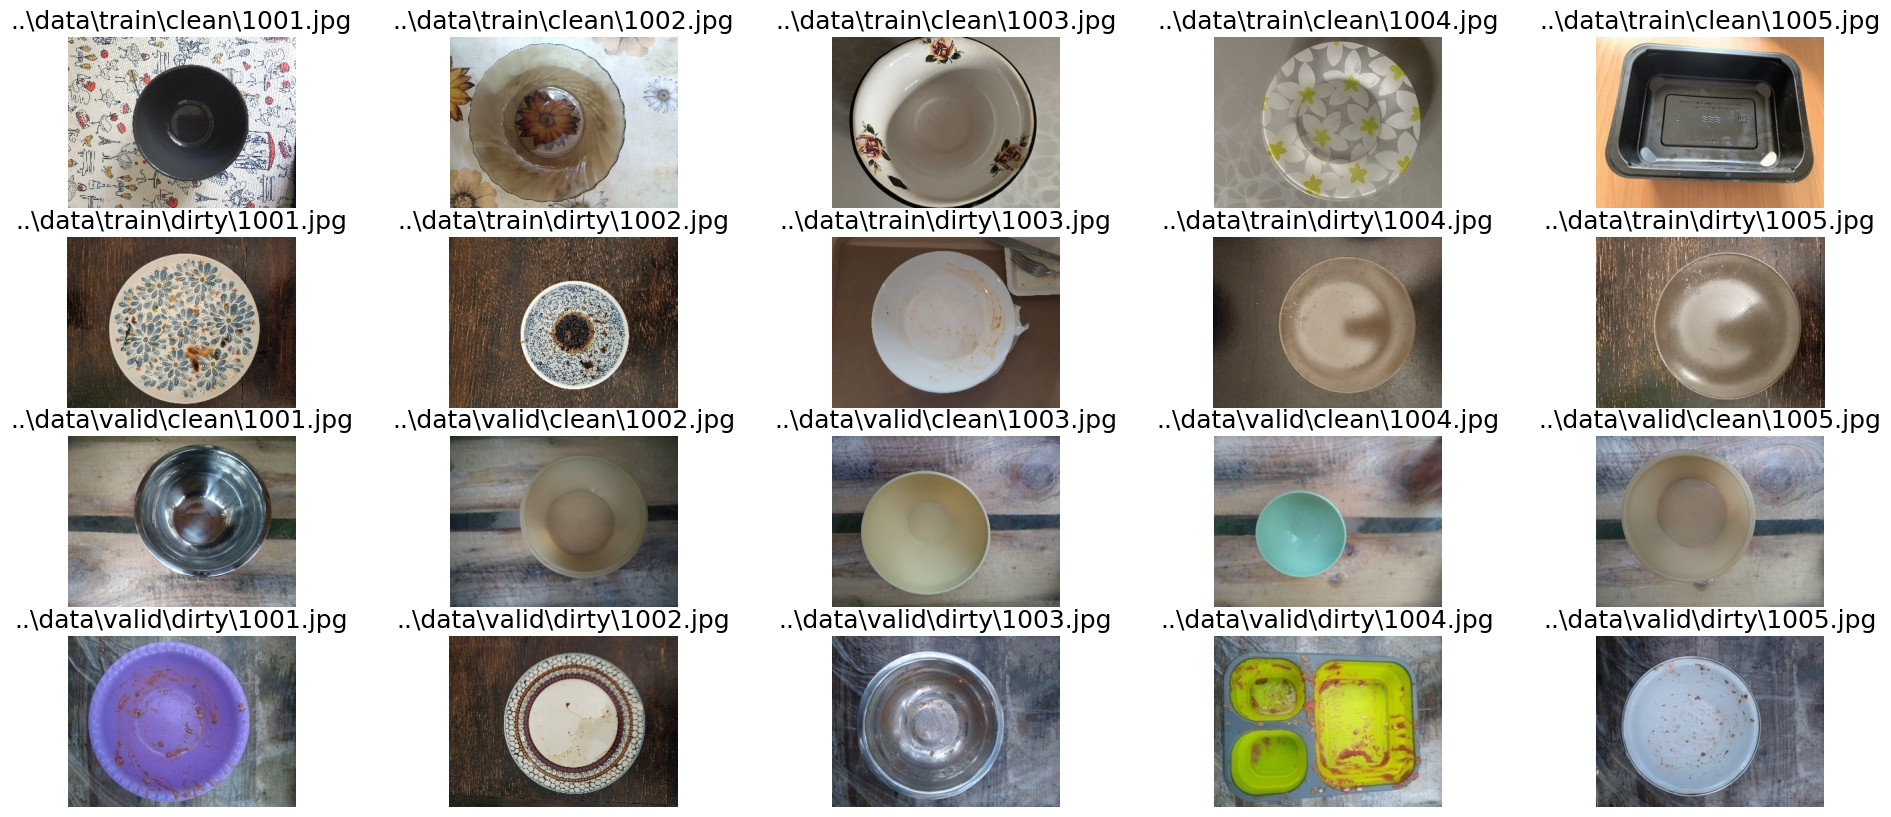

In [ ]:
image_count = 5

fig, axs = plt.subplots(nrows=len(FOLDERS_DATA_TYPE) * len(FOLDERS_CLASS_TYPE), 
                        ncols=image_count, 
                        figsize=(20, 8))

for multiply, data_type_path in enumerate(FOLDERS_DATA_TYPE):
    for row, class_type_path in enumerate(FOLDERS_CLASS_TYPE):
        folder = Path(data_type_path) / class_type_path
        for col, filename in enumerate(folder.iterdir()):
            if col >= image_count:
                break
            if filename.is_file():
                title = f'{filename}'
                current_row = multiply * len(FOLDERS_DATA_TYPE) + row 
                axs[current_row, col].imshow(plt.imread(filename))
                axs[current_row, col].set_title(title, fontsize=18)
                axs[current_row, col].axis('off')

plt.tight_layout(pad=0.1)
plt.show()

In [ ]:
min_width = 100000
min_height = 100000
max_width = 0
max_height = 0

for data_type_path, class_type_path in product(FOLDERS_DATA_TYPE, FOLDERS_CLASS_TYPE):
    folder = Path(data_type_path) / class_type_path
    for filename in folder.iterdir():
        if filename.is_file():
            with Image.open(filename) as img:
                width = img.size[0]
                height = img.size[1]
                if width < min_width:
                    min_width = width
                if height < min_height:
                    min_height = height
                if width > max_width:
                    max_width = width
                if height > max_height:
                    max_height = height
print(f"Width: {min_width} - {max_width}")
print(f"Height: {min_height} - {max_height}")

Width: 192 - 351
Height: 255 - 341


# Спочатку спробую VGG16, бо tinyVGG робив в минулій роботі, тому зведу картинку до 224х224, якщо буде час, спробую мінімізувати до інших (augmentation.py)

In [ ]:
augmantation = AugmentationV1()

train_data = datasets.ImageFolder(
    root=TRAIN_DATA_PATH,
    transform=augmantation.get_train())

valid_data = datasets.ImageFolder(
    root=VALID_DATA_PATH,
    transform=augmantation.get_test())

print(f"Train data:\n{train_data}\nValid data:\n{valid_data}")
CLASS_NAMES = train_data.classes
print(f"Class names: {CLASS_NAMES}")

AttributeError: module 'torchvision.transforms.v2' has no attribute 'HorizontalFlip'

# Створюю dataloaders (ділю на батчі)

In [ ]:
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)
valid_dataloader = DataLoader(
    dataset=valid_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)
print(f'Length of train dataloader: {len(train_dataloader)}')
print(f'Length of valid dataloader: {len(valid_dataloader)}')

Length of train dataloader: 14
Length of valid dataloader: 15


d:\Programming\Python\NN_PlatesClassification\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6392158].


Train features batch shape: torch.Size([32, 3, 128, 128])
Train labels batch shape: torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.88235307].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.992157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.654902..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9294119].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..1.0].
Clipping input data to the valid range f

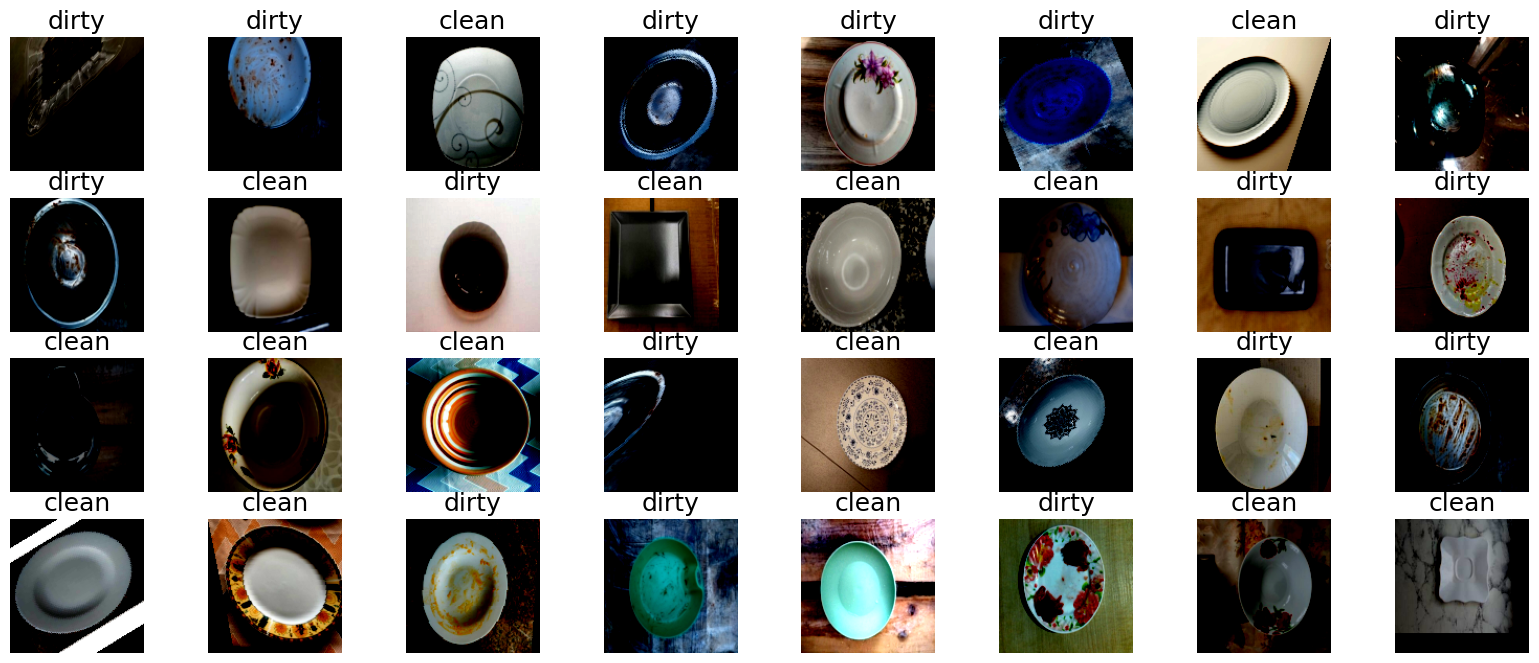

In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f"Train features batch shape: {train_features_batch.shape}")
print(f"Train labels batch shape: {train_labels_batch.shape}")

ncols = 8
fig, axs = plt.subplots(nrows=int(BATCH_SIZE/ncols), ncols=ncols, figsize=(20, 8))
for i in range(BATCH_SIZE):
    axs[i // ncols, i % ncols].imshow(train_features_batch[i].permute(1, 2, 0))
    axs[i // ncols, i % ncols].set_title(f'{CLASS_NAMES[train_labels_batch[i]]}', fontsize=18)
    axs[i // ncols, i % ncols].axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8666667..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..0.39607847].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88235295..0.62352955].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.78039217..0.7019609].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8117647..0.73333347].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.68627465].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.850980

Valid features batch shape: torch.Size([32, 3, 128, 128])
Valid labels batch shape: torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.9058825].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.9058825].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88235295..0.7568629].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90588236..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.74901974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.827451..0.9686276].
C

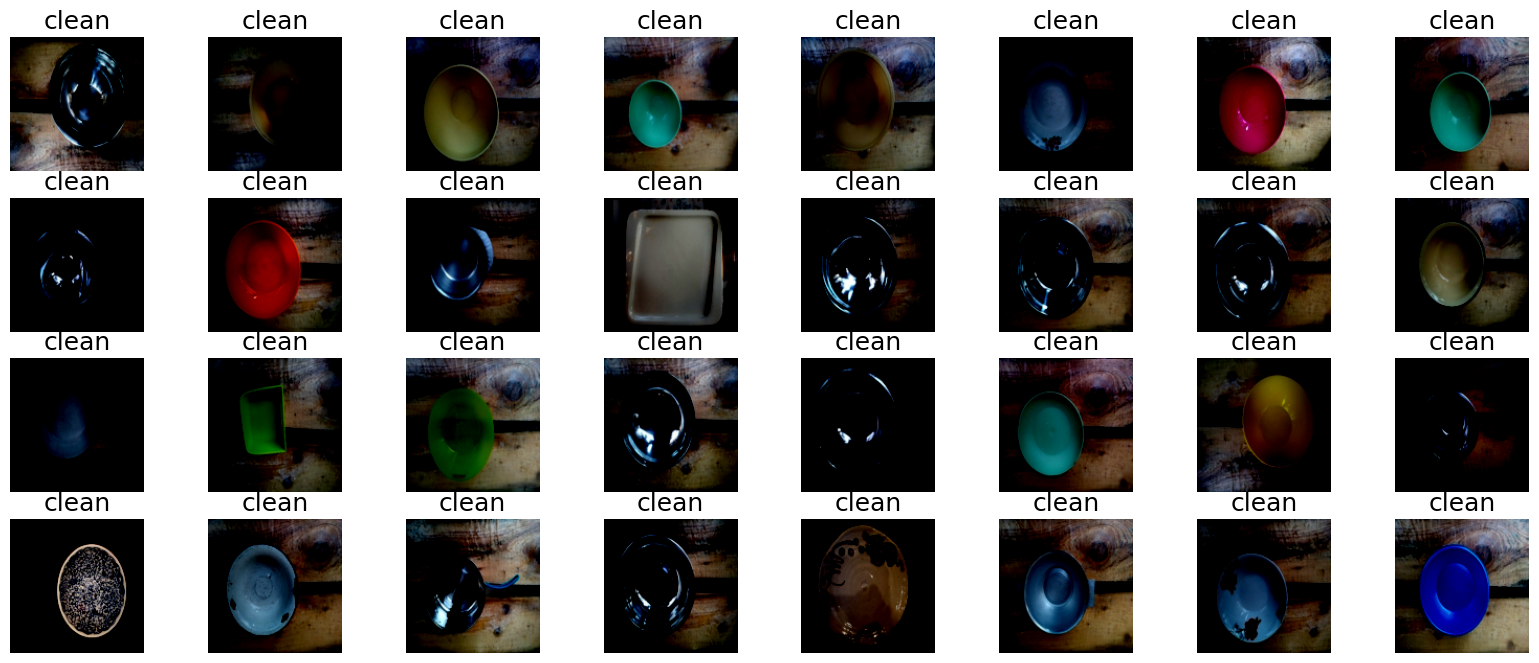

In [ ]:
valid_features_batch, valid_labels_batch = next(iter(valid_dataloader))
print(f"Valid features batch shape: {valid_features_batch.shape}")
print(f"Valid labels batch shape: {valid_labels_batch.shape}")

ncols = 8
fig, axs = plt.subplots(nrows=int(BATCH_SIZE/ncols), ncols=ncols, figsize=(20, 8))
for i in range(BATCH_SIZE):
    axs[i // ncols, i % ncols].imshow(valid_features_batch[i].permute(1, 2, 0))
    axs[i // ncols, i % ncols].set_title(f'{CLASS_NAMES[valid_labels_batch[i]]}', fontsize=18)
    axs[i // ncols, i % ncols].axis('off')

# Створюю згорточну модель (model.py)

In [ ]:
epochs = 100

tinyVgg_v1 = TinyVGG_V1(input_channels=3, output_classes=len(CLASS_NAMES)).to(device)

loss_fn = CrossEntropyLoss().to(device)
accuracy_fn = MulticlassAccuracy(num_classes=len(CLASS_NAMES)).to(device)

optimizer = RAdam(
    params=tinyVgg_v1.parameters(),
    lr=0.01,
)
scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    factor=0.9,
    patience=0,
)

In [ ]:
summary(tinyVgg_v1)

Layer (type:depth-idx)                   Param #
TinyVGG_V1                               --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       448
│    └─BatchNorm2d: 2-2                  32
│    └─ReLU: 2-3                         --
│    └─Conv2d: 2-4                       2,320
│    └─BatchNorm2d: 2-5                  32
│    └─ReLU: 2-6                         --
│    └─MaxPool2d: 2-7                    --
│    └─Dropout: 2-8                      --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-9                       4,640
│    └─BatchNorm2d: 2-10                 64
│    └─ReLU: 2-11                        --
│    └─Conv2d: 2-12                      9,248
│    └─BatchNorm2d: 2-13                 64
│    └─ReLU: 2-14                        --
│    └─MaxPool2d: 2-15                   --
│    └─Dropout: 2-16                     --
├─Sequential: 1-3                        --
│    └─Conv2d: 2-17                      18,496
│    └─BatchN

In [ ]:
train(
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    model=tinyVgg_v1,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    optimizer=optimizer,
    epochs=epochs,
    scheduler=scheduler,
)

NameError: name 'train_dataloader' is not defined

In [ ]:
epochs = 100

tinyVgg_v1 = TinyVGG_V1(input_channels=3, output_classes=len(CLASS_NAMES)).to(device)

loss_fn = CrossEntropyLoss().to(device)
accuracy_fn = MulticlassAccuracy(num_classes=len(CLASS_NAMES)).to(device)

optimizer = RAdam(
    params=tinyVgg_v1.parameters(),
    lr=0.005,
)
scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    factor=0.9,
    patience=0,
)

In [ ]:
train(
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    model=tinyVgg_v1,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    optimizer=optimizer,
    epochs=epochs,
    scheduler=scheduler,
)